# 01 — Intrinsic population simulation

In this notebook we generate the intrinsic binary-neutron-star population.

There is no detector model here: no SNR, no selection effects, no mock parameter estimation. Those enter in the next notebook.

We use the polynomial `log Lambda(m)` surrogate produced in notebook 00.


## Colab setup

If running on Colab, first clone the repository and enter it. If running locally from the repository root, skip this cell.


In [ ]:
# Run this cell only on Colab.
# !git clone https://github.com/Mik3M4n/ns-eos-population-tutorial.git
# %cd ns-eos-population-tutorial
# !pip install -r requirements.txt


## Imports and paths


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from astropy.cosmology import Planck18 as cosmology

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

processed_dir = project_root / 'data/processed'
figures_dir = project_root / 'figures'

processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)


## Load the EOS polynomial fit from notebook 00


In [2]:
eos_fit = np.load(processed_dir / 'bsk24_loglambda_polyfit.npz')

fit_min = float(eos_fit['fit_min'])
fit_max = float(eos_fit['fit_max'])
eos_chosen_order = int(eos_fit['chosen_order'])
eos_chosen_coeffs = eos_fit['chosen_coeffs']

def lambda_of_mass(m):
    return np.exp(np.polyval(eos_chosen_coeffs, m))

print(f'EOS polynomial order: {eos_chosen_order}')
print(f'EOS fit interval: {fit_min:.3f} -- {fit_max:.3f} Msun')


EOS polynomial order: 5
EOS fit interval: 1.000 -- 2.250 Msun


## Simulation choices


In [17]:
# Main choices to modify.
seed = 12345
n_events = 100_000

# Use the same mass interval as the EOS polynomial fit.
m_min_true = fit_min
m_max_true = fit_max
edge_width_true = 0.05
edge_pdf_value = 1e-10

# Madau-Dickinson-like rate parameters.
z_max = 20.0
alpha_z = 2.7
beta_z = 2.9
z_p = 1.9

rng = np.random.default_rng(seed)


## Mass distribution

We draw each component mass from a smoothed box distribution,

$$p(m) \propto \sigma\left(\frac{m-m_{\min}}{\Delta m}\right)\sigma\left(\frac{m_{\max}-m}{\Delta m}\right),$$

then sort the two components so that $m_1 \ge m_2$.


In [19]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def mass_pdf(m):
    logit_edge = np.log((1.0 - edge_pdf_value) / edge_pdf_value)
    edge_scale = edge_width_true / logit_edge

    left = sigmoid((m - m_min_true - edge_width_true) / edge_scale)
    right = sigmoid((m_max_true - edge_width_true - m) / edge_scale)

    return left * right

m_grid = np.linspace(m_min_true, m_max_true, 5000)
p_m_grid = mass_pdf(m_grid)
p_m_max = p_m_grid.max()

def draw_masses(n):
    draws = []
    while len(draws) < 2 * n:
        proposal = rng.uniform(m_min_true, m_max_true, size=2 * n)
        accept_prob = mass_pdf(proposal) / p_m_max
        accepted = proposal[rng.uniform(size=proposal.size) < accept_prob]
        draws.extend(accepted.tolist())

    masses = np.array(draws[:2 * n]).reshape(n, 2)
    m1 = np.maximum(masses[:, 0], masses[:, 1])
    m2 = np.minimum(masses[:, 0], masses[:, 1])
    return m1, m2

m1, m2 = draw_masses(n_events)

print(f'm1 range: {m1.min():.3f} -- {m1.max():.3f} Msun')
print(f'm2 range: {m2.min():.3f} -- {m2.max():.3f} Msun')


m1 range: 1.052 -- 2.212 Msun
m2 range: 1.037 -- 2.195 Msun


## Redshift distribution

We draw redshifts from the observed-frame distribution

$$p(z) \propto \frac{R(z)}{1+z}\frac{dV_c}{dz},$$

with

$$R(z) \propto \frac{(1+z)^{\alpha_z}}{1 + \left[(1+z)/(1+z_p)\right]^{\alpha_z+\beta_z}}.$$


In [9]:
def merger_rate_density(z):
    numerator = (1.0 + z) ** alpha_z
    denominator = 1.0 + ((1.0 + z) / (1.0 + z_p)) ** (alpha_z + beta_z)
    return numerator / denominator

def redshift_pdf_unnormalized(z):
    dvc_dz = cosmology.differential_comoving_volume(z).value
    return merger_rate_density(z) * dvc_dz / (1.0 + z)

z_grid = np.linspace(0.0, z_max, 5000)
p_z_grid = redshift_pdf_unnormalized(z_grid)
p_z_max = p_z_grid.max()

def draw_redshifts(n):
    draws = []
    while len(draws) < n:
        proposal = rng.uniform(0.0, z_max, size=n)
        accept_prob = redshift_pdf_unnormalized(proposal) / p_z_max
        accepted = proposal[rng.uniform(size=proposal.size) < accept_prob]
        draws.extend(accepted.tolist())
    return np.array(draws[:n])

z = draw_redshifts(n_events)
d_l = cosmology.luminosity_distance(z).value

print(f'z range: {z.min():.4f} -- {z.max():.4f}')
print(f'd_L range: {d_l.min():.2f} -- {d_l.max():.2f} Mpc')


z range: 0.0464 -- 19.8110
d_L range: 212.67 -- 227691.72 Mpc


## Derived quantities


In [20]:
m1_det = m1 * (1.0 + z)
m2_det = m2 * (1.0 + z)

lambda1 = lambda_of_mass(m1)
lambda2 = lambda_of_mass(m2)

lambda_tilde = (16.0 / 13.0) * (
    (m1 + 12.0 * m2) * m1**4 * lambda1
    + (m2 + 12.0 * m1) * m2**4 * lambda2
) / (m1 + m2) ** 5

print(f'Lambda_1 range: {lambda1.min():.2f} -- {lambda1.max():.2f}')
print(f'Lambda_2 range: {lambda2.min():.2f} -- {lambda2.max():.2f}')
print(f'tilde Lambda range: {lambda_tilde.min():.2f} -- {lambda_tilde.max():.2f}')


Lambda_1 range: 11.75 -- 2530.69
Lambda_2 range: 13.30 -- 2736.07
tilde Lambda range: 12.95 -- 2545.81


## Diagnostic plots


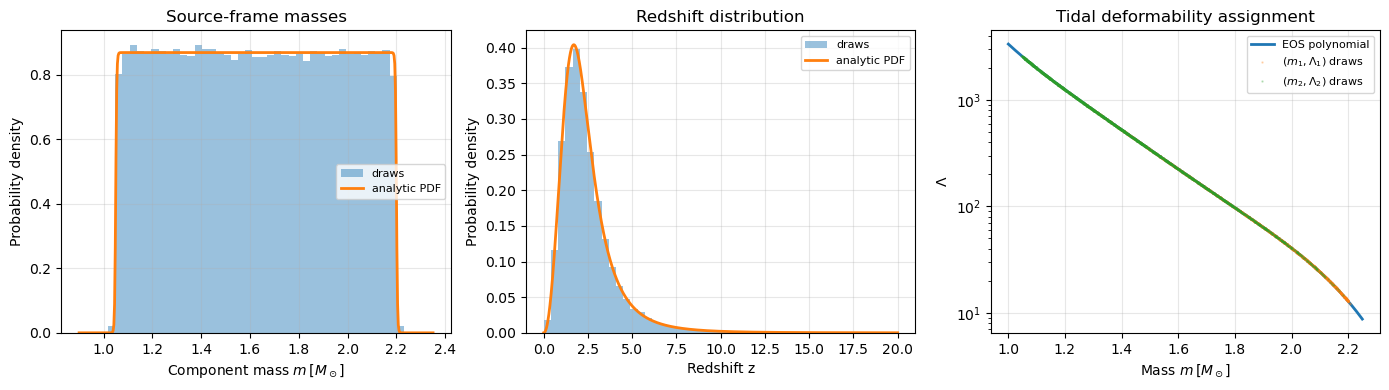

Saved figure to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/figures/intrinsic_population_polytruth.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.0))

ax = axes[0]
bins_m = np.linspace(m_min_true - 0.1, m_max_true + 0.1, 50)
ax.hist(np.concatenate([m1, m2]), bins=bins_m, density=True, alpha=0.45, label='draws')

m_plot = np.linspace(m_min_true - 0.1, m_max_true + 0.1, 500)
p_m_plot = mass_pdf(m_plot)
p_m_plot /= np.trapezoid(p_m_plot, m_plot)
ax.plot(m_plot, p_m_plot, lw=2.0, label='analytic PDF')
ax.set_xlabel(r'Component mass $m\,[M_\odot]$')
ax.set_ylabel('Probability density')
ax.set_title('Source-frame masses')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
bins_z = np.linspace(0.0, z_max, 50)
ax.hist(z, bins=bins_z, density=True, alpha=0.45, label='draws')

p_z_plot = redshift_pdf_unnormalized(z_grid)
p_z_plot /= np.trapezoid(p_z_plot, z_grid)
ax.plot(z_grid, p_z_plot, lw=2.0, label='analytic PDF')
ax.set_xlabel('Redshift z')
ax.set_ylabel('Probability density')
ax.set_title('Redshift distribution')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[2]
m_eos = np.linspace(m_min_true, m_max_true, 500)
ax.plot(m_eos, lambda_of_mass(m_eos), lw=2.0, label='EOS polynomial')
ax.plot(m1[:3000], lambda1[:3000], '.', ms=1.5, alpha=0.25, label=r'$(m_1,\Lambda_1)$ draws')
ax.plot(m2[:3000], lambda2[:3000], '.', ms=1.5, alpha=0.25, label=r'$(m_2,\Lambda_2)$ draws')
ax.set_yscale('log')
ax.set_xlabel(r'Mass $m\,[M_\odot]$')
ax.set_ylabel(r'$\Lambda$')
ax.set_title('Tidal deformability assignment')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.tight_layout()
figure_path = figures_dir / 'intrinsic_population_polytruth.png'
fig.savefig(figure_path, dpi=200)
plt.show()

print(f'Saved figure to {figure_path}')


## Save intrinsic population


In [22]:
output_path = processed_dir / 'intrinsic_population_polytruth.npz'

np.savez(
    output_path,
    seed=seed,
    n_events=n_events,
    m_min_true=m_min_true,
    m_max_true=m_max_true,
    edge_width_true=edge_width_true,
    edge_pdf_value=edge_pdf_value,
    z_max=z_max,
    alpha_z=alpha_z,
    beta_z=beta_z,
    z_p=z_p,
    eos_chosen_order=eos_chosen_order,
    eos_chosen_coeffs=eos_chosen_coeffs,
    m1=m1,
    m2=m2,
    z=z,
    d_l=d_l,
    m1_det=m1_det,
    m2_det=m2_det,
    lambda1=lambda1,
    lambda2=lambda2,
    lambda_tilde=lambda_tilde,
)

print(f'Saved intrinsic population to {output_path}')


Saved intrinsic population to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/data/processed/intrinsic_population_polytruth.npz
